In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configurable paths

# Promoter-level chec-seq binding signal (sumprom) for Human TFs
sumprom_chec_glob = "sumproms/*gz"

# Promoter-level chec-seq binding signal (sumprom) for yeast TFs (see manuscript)
yeast_tf_sumprom_glob = '../Yeast_Native_TF_outfiles/results/sumproms/*.gz'

# Promoter-level chec-seq signal (sumprom) for yeast DBD-only variants (see manuscript)
yeast_dbd_variants_glob = "../divya_dbds/results/sumproms/*.gz"

# OPN scores per promoter
opn_scores_glob = "metadata/comp_gp.csv"

## Imports

In [3]:
import numpy as np
import pandas as pd

import glob

from scipy.stats import zscore
from scipy.stats import spearmanr

import matplotlib.pyplot as plt
import seaborn as sns

## Load data

In [4]:
FOXK1_WT = ["FOXP3","FOXA2","FOXF1","FOXL1","FOXL2","FOXJ2","FOXO3","FOXP1","FOXP2"]
GABPA_WT = ["ELF1","ELF2","ERF1","ELK1","ELK4","ERG","FLI1"]
SOX10_WT = ["SOX15","SOX17","SOX7","SOX11","SOX4","SOX6","SOX30","SOX9","SOX13","SOX5"]
HXD10_WT = ["CDX2","HOXA11","HOXC10","HOXD9","HOXA10","HOXC9","HOXA9","HOXB9","CDX4","HOXC13"]
GATA1_WT = ["GATA3","GATA6","GATA4","GATA2","GATA5"]
BATF3_WT = ["ATF4","FOS","CREB5","ATF1","CREB1","ATF2"]
HEY1_WT = ["MNT","MLXIPL","MLX","MXD4"]
NFAC4_WT = ["NFATC4","NFATC3"]
TF2LY_WT = ["TGIF2LX","TGIF2LY","TGIF1","TGIF2"]
PO3F2_WT = ["POU2F3","POU3F4","POU3F1"]

dbd_fam_dict = {"FOXK1": FOXK1_WT, "GABPA": GABPA_WT, "SOX10": SOX10_WT, "HXD10": HXD10_WT, "GATA1": GATA1_WT, "BATF3": BATF3_WT, "HEY1": HEY1_WT, "NFAC4": NFAC4_WT, "TF2LY": TF2LY_WT, "PO3F2": PO3F2_WT}

In [5]:
sumprom_chec_files = glob.glob(sumprom_chec_glob)
sumprom_all = pd.concat([pd.read_parquet(x) for x in sumprom_chec_files], axis=1)

corr_cutoff = 0.895

def filter_reproducible(sumprom_all: pd.DataFrame, cutoff) -> pd.DataFrame:
    df = sumprom_all.copy()
    groups = pd.Series(df.columns, index=df.columns).str.rsplit("_", n=2).str[0]
    
    keep = []
    for _, members in groups.groupby(groups).groups.items():
        if len(members) < 2:
            continue
        corr = df[members].corr()
        np.fill_diagonal(corr.values, np.nan)
        max_corrs = corr.max(axis=1)
        reproducible = max_corrs[max_corrs >= cutoff].index.tolist()
        keep.extend(reproducible)
    return df[keep]

sumprom_filtered = filter_reproducible(sumprom_all, cutoff=corr_cutoff)
cols = sumprom_filtered.columns.astype(str)
base_sumprom = cols.str.rsplit('_', n=2).str[0]
cols_to_keep = set(sum(dbd_fam_dict.values(), []))
sumprom = sumprom_filtered.T.groupby(base_sumprom).mean().T
sumprom = sumprom.loc[:, sumprom.columns.intersection(cols_to_keep)]
sumprom_z = sumprom.apply(zscore)

In [6]:
native_tf_sumprom_files = glob.glob(yeast_tf_sumprom_glob)
native_tf_sumprom = pd.concat([pd.read_parquet(x) for x in native_tf_sumprom_files], axis=1)
non_transcription_factors = ['Nfi1', 'Itc1', 'Gal11', 'Nhp6A', 'Spt20', 'Nhp6B','Abf2', 'Tog1', 'Siz1', 'Cyc8', "Mss11"]
native_tf_sumprom = native_tf_sumprom.drop(columns=non_transcription_factors)
native_tf_sumprom_z = native_tf_sumprom.apply(zscore)

In [7]:
dbd_chec_files = glob.glob(yeast_dbd_variants_glob)
dbd_sumprom_reps = pd.concat([pd.read_parquet(x) for x in dbd_chec_files], axis=1)
dbd_sumprom_filtered = filter_reproducible(dbd_sumprom_reps, cutoff=corr_cutoff)
cols = pd.Index(dbd_sumprom_filtered.columns)
prefix = cols.to_series().str.rsplit("_", n=3).str[0]
sumprom_dbd = dbd_sumprom_filtered.T.groupby(prefix).mean().T
sumprom_dbd.columns = sumprom_dbd.columns.astype(str) + "_DBD"
sumprom_dbd_z = sumprom_dbd.apply(zscore)

In [8]:
opn_scores_unfiltered = pd.read_csv(opn_scores_glob, index_col='name').iloc[:,1:]
opn_scores = opn_scores_unfiltered[opn_scores_unfiltered.index.isin(sumprom.index)]

## Plot

/home/labs/barkailab/joshuabu/miniconda3/envs/analysis2/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/home/labs/barkailab/joshuabu/miniconda3/envs/analysis2/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


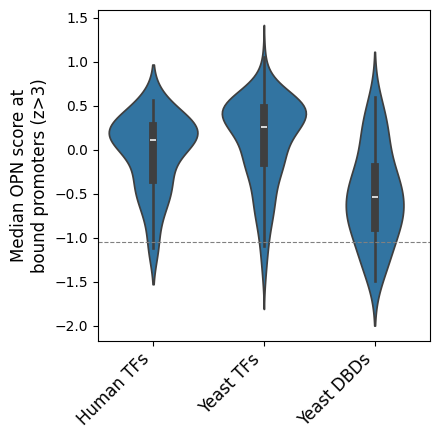

In [9]:
z_cutoff = 3

opn_all = opn_scores["opn_score"]

human_medians = [
    opn_scores.loc[sumprom_z[c] > z_cutoff, "opn_score"].median()
    for c in sumprom_z.columns
    if (sumprom_z[c] > z_cutoff).any()
]

yeast_medians = [
    opn_scores.loc[native_tf_sumprom_z[c] > z_cutoff, "opn_score"].median()
    for c in native_tf_sumprom_z.columns
    if (native_tf_sumprom_z[c] > z_cutoff).any()
]

dbd_medians = [
    opn_scores.loc[sumprom_dbd_z[c] > z_cutoff, "opn_score"].median()
    for c in sumprom_dbd_z.columns
    if (sumprom_dbd_z[c] > z_cutoff).any()
]

df_plot = pd.DataFrame({
    "OPN_median": human_medians + yeast_medians + dbd_medians,
    "Group": ["Human TFs"] * len(human_medians) + ["Yeast TFs"] * len(yeast_medians) + ["Yeast DBDs"] * len(dbd_medians)
})

plt.figure(figsize=(4.5, 4.5))
sns.violinplot(data=df_plot, x="Group", y="OPN_median", inner="box")
plt.axhline(opn_all.median(), linestyle="--", color="gray", linewidth=0.8)
plt.ylabel(f"Median OPN score at\nbound promoters (z>{z_cutoff})", fontsize=12)
plt.xlabel("")
plt.xticks(fontsize=12, rotation=45, ha="right")
plt.tight_layout()
plt.show()